# 🌍 Hackathon #26 — Exploration des données climatiques
## Notebook 01 : Analyse Exploratoire (EDA)

**Objectif** : Comprendre la structure, la qualité et les tendances des données climatiques avant modélisation.

**Plan** :
1. Chargement et aperçu des données
2. Qualité des données (valeurs manquantes, outliers)
3. Statistiques descriptives
4. Visualisation des tendances historiques
5. Corrélations entre indicateurs
6. Analyse décennale


In [1]:
# ─── Imports ───
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

from config.settings import PROCESSED_DIR, RAW_DIR

# Style
plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Imports OK')

✅ Imports OK


## 1. Chargement des données

In [ ]:
# Chargement du master dataset (après pipeline)
master_path = PROCESSED_DIR / 'master_features.parquet'

if master_path.exists():
    df = pd.read_parquet(master_path)
    print(f' Master dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
else:
    # Génération directe pour le notebook
    from src.ingestion.pipeline import DataPipeline
    from src.processing.cleaner import DataCleaner
    from src.processing.transformer import DataTransformer
    
    print('⚙️ Pipeline en cours...')
    DataPipeline().run()
    DataCleaner().clean_all()
    DataTransformer().run()
    df = pd.read_parquet(master_path)
    print(f'✅ {df.shape}')

df.head(10)

✅ Master dataset chargé : 125 lignes × 28 colonnes


,annee,temp_moy_c,jours_chauds_30,jours_gel,precip_mm,anomalie_temp_c,trend_temp_10ans,indice_chaleur,deficit_precip_pct,annee_seche,co2_ppm,co2_variation_annuelle,co2_acceleration,ges_total_mtco2eq,ges_variation_pct,ges_vs_1990_pct,objectif_2030_ecart,empreinte_totale_tco2eq,part_importee_tco2eq,score_risque_climatique,temp_moy_c_lag1,temp_moy_c_lag2,temp_moy_c_lag3,temp_moy_c_lag5,temp_moy_c_lag10,co2_ppm_lag1,co2_ppm_lag2,co2_ppm_lag5
0,1900,12.120,10.240,68,726.400,-0.949,NaN,0.000,6.020,0,296.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1901,11.980,12.000,60,710.100,-1.089,NaN,4.569,3.640,0,296.330,0.330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.700,12.120,NaN,NaN,NaN,NaN,296.000,NaN,NaN
2,1902,12.190,10.240,60,801.700,-0.879,NaN,0.000,17.010,0,296.670,0.340,0.010,NaN,NaN,NaN,NaN,NaN,NaN,29.100,11.980,12.120,NaN,NaN,NaN,296.330,296.000,NaN
3,1903,12.420,12.000,65,780.300,-0.649,NaN,4.569,13.890,0,297.000,0.330,-0.010,NaN,NaN,NaN,NaN,NaN,NaN,33.000,12.190,11.980,12.120,NaN,NaN,296.670,296.330,NaN
4,1904,12.000,11.000,60,745.700,-1.069,0.200,1.973,8.840,0,297.330,0.330,0.000,NaN,NaN,NaN,NaN,NaN,NaN,27.400,12.420,12.190,11.980,NaN,NaN,297.000,296.670,NaN
5,1905,12.010,11.000,58,660.700,-1.059,-0.074,1.973,-3.570,0,297.670,0.340,0.010,NaN,NaN,NaN,NaN,NaN,NaN,27.600,12.000,12.420,12.190,12.120,NaN,297.330,297.000,296.000
6,1906,12.480,13.000,52,670.300,-0.589,0.339,7.165,-2.170,0,298.000,0.330,-0.010,NaN,NaN,NaN,NaN,NaN,NaN,34.500,12.010,12.000,12.420,11.980,NaN,297.670,297.330,296.330
7,1907,12.290,12.000,53,648.200,-0.779,0.325,4.569,-5.390,0,298.330,0.330,0.000,NaN,NaN,NaN,NaN,NaN,NaN,31.600,12.480,12.010,12.000,12.190,NaN,298.000,297.670,296.670
8,1908,11.990,15.000,61,712.100,-1.079,0.097,12.357,3.930,0,298.670,0.340,0.010,NaN,NaN,NaN,NaN,NaN,NaN,30.000,12.290,12.480,12.010,12.420,NaN,298.330,298.000,297.000
9,1909,12.260,13.000,63,560.800,-0.809,0.122,7.165,-18.150,1,299.000,0.330,-0.010,NaN,NaN,NaN,NaN,NaN,NaN,31.900,11.990,12.290,12.480,12.000,NaN,298.670,298.330,297.330


In [3]:
# Aperçu général
print('📊 Informations générales')
print('=' * 50)
print(f'Période couverte : {df["annee"].min()} → {df["annee"].max()}')
print(f'Nombre de variables : {len(df.columns)}')
print()
print('Variables disponibles :')
for col in df.columns:
    pct_missing = df[col].isna().mean() * 100
    print(f'  {col:<35} | missing: {pct_missing:5.1f}% | type: {df[col].dtype}')

📊 Informations générales
Période couverte : 1900 → 2024
Nombre de variables : 28

Variables disponibles :
  annee                               | missing:   0.0% | type: int64
  temp_moy_c                          | missing:   0.0% | type: float64
  jours_chauds_30                     | missing:   0.0% | type: float64
  jours_gel                           | missing:   0.0% | type: int64
  precip_mm                           | missing:   0.0% | type: float64
  anomalie_temp_c                     | missing:   0.0% | type: float64
  trend_temp_10ans                    | missing:   3.2% | type: float64
  indice_chaleur                      | missing:   0.0% | type: float64
  deficit_precip_pct                  | missing:   0.0% | type: float64
  annee_seche                         | missing:   0.0% | type: int64
  co2_ppm                             | missing:   0.8% | type: float64
  co2_variation_annuelle              | missing:   2.4% | type: float64
  co2_acceleration                  

## 2. Qualité des données

/var/folders/27/d1jhk2p13dnchc234sc4ry740000gn/T/ipykernel_32449/3136794959.py:12: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/Users/raphc/Downloads/hackathon26_climat/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


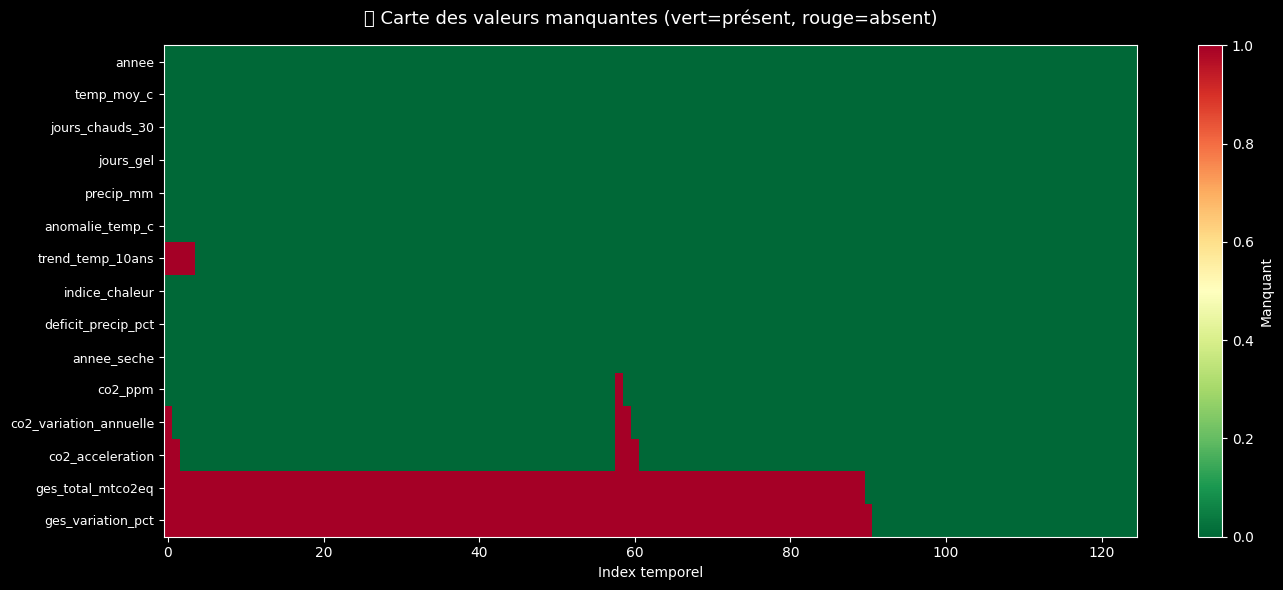

,colonne,n_manquants,pct_manquants
14,ges_variation_pct,91,72.800
13,ges_total_mtco2eq,90,72.000
12,co2_acceleration,5,4.000
6,trend_temp_10ans,4,3.200
11,co2_variation_annuelle,3,2.400
10,co2_ppm,1,0.800
0,annee,0,0.000
1,temp_moy_c,0,0.000
2,jours_chauds_30,0,0.000
3,jours_gel,0,0.000


In [4]:
# Heatmap des valeurs manquantes
num_cols = df.select_dtypes(include=np.number).columns.tolist()[:15]

fig, ax = plt.subplots(figsize=(14, 6))
missing_matrix = df[num_cols].isna().astype(int)
im = ax.imshow(missing_matrix.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=9)
ax.set_xlabel('Index temporel')
ax.set_title('🔍 Carte des valeurs manquantes (vert=présent, rouge=absent)', fontsize=13, pad=15)
plt.colorbar(im, ax=ax, label='Manquant')
plt.tight_layout()
plt.show()

# Statistiques des manquants
missing_stats = pd.DataFrame({
    'colonne': num_cols,
    'n_manquants': [df[c].isna().sum() for c in num_cols],
    'pct_manquants': [df[c].isna().mean()*100 for c in num_cols],
}).sort_values('pct_manquants', ascending=False)
missing_stats

## 3. Statistiques descriptives

In [5]:
# Stats descriptives des variables clés
cols_cles = [c for c in ['temp_moy_c', 'anomalie_temp_c', 'co2_ppm', 
                          'jours_chauds_30', 'jours_gel', 'precip_mm',
                          'ges_total_mtco2eq', 'empreinte_totale_tco2eq',
                          'score_risque_climatique'] if c in df.columns]

stats = df[cols_cles].describe().round(2)
print('📊 Statistiques descriptives — Variables clés')
stats

📊 Statistiques descriptives — Variables clés


,temp_moy_c,anomalie_temp_c,co2_ppm,jours_chauds_30,jours_gel,precip_mm,ges_total_mtco2eq,empreinte_totale_tco2eq,score_risque_climatique
count,125.000,125.000,124.000,125.000,125.000,125.000,35.000,30.000,125.000
mean,12.870,-0.200,334.640,21.950,51.920,687.520,424.880,11.220,47.740
std,0.660,0.660,36.220,7.300,6.540,53.830,78.490,0.800,15.150
min,11.800,-1.270,296.000,10.240,35.000,556.600,304.590,9.910,18.500
25%,12.320,-0.750,306.250,17.000,47.000,658.000,360.520,10.610,35.600
50%,12.890,-0.180,318.720,21.000,52.000,687.700,423.810,11.220,45.800
75%,13.310,0.240,357.650,27.000,57.000,723.800,486.670,11.790,57.800
max,15.170,2.100,424.610,48.760,68.000,835.300,558.300,12.600,99.500


## 4. Tendances historiques

In [6]:
# Dashboard multi-panneaux : évolution des indicateurs clés
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        '🌡️ Température moyenne annuelle',
        '🏭 CO₂ atmosphérique (ppm)',
        '☀️ Jours > 30°C par an',
        '❄️ Jours de gel par an',
        '🌧️ Précipitations annuelles (mm)',
        '⚠️ Score de risque climatique',
    ),
    vertical_spacing=0.12,
)

config_plots = [
    ('temp_moy_c', 1, 1, '#fd79a8'),
    ('co2_ppm', 1, 2, '#fdcb6e'),
    ('jours_chauds_30', 2, 1, '#e17055'),
    ('jours_gel', 2, 2, '#74b9ff'),
    ('precip_mm', 3, 1, '#00cec9'),
    ('score_risque_climatique', 3, 2, '#a29bfe'),
]

for col, row, col_n, color in config_plots:
    if col not in df.columns:
        continue
    df_clean = df.dropna(subset=[col])
    
    # Série brute
    fig.add_trace(go.Scatter(
        x=df_clean['annee'], y=df_clean[col],
        mode='lines', line=dict(color=color, width=1),
        opacity=0.5, showlegend=False,
    ), row=row, col=col_n)
    
    # Moyenne mobile 10 ans
    rolling = df_clean[col].rolling(10, center=True).mean()
    fig.add_trace(go.Scatter(
        x=df_clean['annee'], y=rolling,
        mode='lines', line=dict(color=color, width=2.5),
        name=col, showlegend=False,
    ), row=row, col=col_n)

fig.update_layout(
    height=900, template='plotly_dark',
    title_text='📈 Évolution des indicateurs climatiques clés — France 1900-2024',
    title_font_size=16,
)
fig.show()

In [7]:
# Anomalie de température : visualisation type GIEC (barres rouges/bleues)
if 'anomalie_temp_c' in df.columns:
    df_anom = df.dropna(subset=['anomalie_temp_c'])
    colors_anom = ['#e74c3c' if v > 0 else '#3498db' for v in df_anom['anomalie_temp_c']]
    
    fig_anom = go.Figure(go.Bar(
        x=df_anom['annee'],
        y=df_anom['anomalie_temp_c'],
        marker_color=colors_anom,
        name='Anomalie',
    ))
    fig_anom.update_layout(
        title='🌡️ Anomalie de température France vs normale 1961-1990',
        template='plotly_dark', height=400,
        xaxis_title='Année', yaxis_title='Anomalie (°C)',
    )
    fig_anom.show()

## 5. Matrice de corrélation

In [8]:
# Corrélations entre les indicateurs principaux
core_cols = [c for c in [
    'temp_moy_c', 'anomalie_temp_c', 'co2_ppm', 'ch4_ppb',
    'jours_chauds_30', 'jours_gel', 'precip_mm',
    'ges_total_mtco2eq', 'empreinte_totale_tco2eq', 'score_risque_climatique'
] if c in df.columns]

corr_matrix = df[core_cols].corr().round(2)

fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='🔗 Matrice de corrélation — Indicateurs climatiques',
    template='plotly_dark',
    height=600,
)
fig_corr.show()

# Top corrélations avec la température
if 'temp_moy_c' in corr_matrix.columns:
    print('\n🌡️ Top corrélations avec la température :')
    print(corr_matrix['temp_moy_c'].sort_values(ascending=False).to_string())


🌡️ Top corrélations avec la température :
temp_moy_c                 1.000
anomalie_temp_c            1.000
score_risque_climatique    0.960
jours_chauds_30            0.920
co2_ppm                    0.830
precip_mm                 -0.160
empreinte_totale_tco2eq   -0.430
ges_total_mtco2eq         -0.490
jours_gel                 -0.650


## 6. Analyse décennale

In [9]:
# Résumé par décennie
df['decennie'] = (df['annee'] // 10 * 10).astype(str) + 's'

agg_cols = [c for c in ['temp_moy_c', 'co2_ppm', 'jours_chauds_30'] if c in df.columns]
decennal = df.groupby('decennie')[agg_cols].mean().round(2)

print('📊 Moyennes décennales — Indicateurs clés')
print(decennal.to_string())

# Variation entre la première et la dernière décennie
if len(decennal) >= 2:
    print('\n📈 Variations 1900s → 2020s :')
    for col in agg_cols:
        delta = decennal[col].iloc[-1] - decennal[col].iloc[0]
        pct = delta / decennal[col].iloc[0] * 100
        print(f'  {col:<25} : {delta:+.2f} ({pct:+.1f}%)')

📊 Moyennes décennales — Indicateurs clés
          temp_moy_c  co2_ppm  jours_chauds_30
decennie                                      
1900s         12.170  297.500           11.950
1910s         12.020  300.830           13.500
1920s         12.280  304.170           16.200
1930s         12.400  307.500           17.600
1940s         12.550  310.830           17.900
1950s         12.800  314.070           19.800
1960s         12.880  320.290           21.900
1970s         13.090  330.860           24.100
1980s         13.180  345.650           25.400
1990s         13.260  360.580           26.200
2000s         13.600  378.770           30.300
2010s         13.740  400.410           32.580
2020s         13.930  418.970           33.950

📈 Variations 1900s → 2020s :
  temp_moy_c                : +1.76 (+14.5%)
  co2_ppm                   : +121.47 (+40.8%)
  jours_chauds_30           : +22.00 (+184.1%)


In [10]:
# Points remarquables (records)
print('🏆 Records historiques')
print('=' * 50)
for col in ['temp_moy_c', 'jours_chauds_30', 'co2_ppm']:
    if col not in df.columns:
        continue
    max_val = df[col].max()
    max_yr = df.loc[df[col].idxmax(), 'annee']
    min_val = df[col].min()
    min_yr = df.loc[df[col].idxmin(), 'annee']
    print(f'{col}:')
    print(f'  Max : {max_val:.2f} en {max_yr:.0f}')
    print(f'  Min : {min_val:.2f} en {min_yr:.0f}')

🏆 Records historiques
temp_moy_c:
  Max : 15.17 en 2019
  Min : 11.80 en 1913
jours_chauds_30:
  Max : 48.76 en 2019
  Min : 10.24 en 1900
co2_ppm:
  Max : 424.61 en 2024
  Min : 296.00 en 1900


## ✅ Conclusions EDA

**Tendances claires identifiées :**
- Réchauffement net sur la période 1900-2024 (+~1.7°C en France)
- Hausse continue du CO₂ (296 ppm → ~423 ppm)
- Augmentation du nombre de jours de chaleur extrême
- Forte corrélation CO₂ ↔ Température

**Points d'attention pour la modélisation :**
- Données GES disponibles seulement depuis 1990
- Empreinte carbone depuis 1995
- Valeurs manquantes interpolées pour les séries courtes

**Prochaine étape :** Notebook 02 — Modélisation IA & Projections
